In [1]:
# !pip install pandas

In [ ]:
import pandas as pd

df = pd.DataFrame({
    'temperature': [10, 7, 4, 0], # temperature: 기온 데이터 -> 입력값 X
    'sales': [30, 50, 60, 80]     # sales: 실제 떡볶이 판매량 -> 정답 y
})

display(df)

,temperature,sales
0,10,30
1,7,50
2,4,60
3,0,80


In [ ]:
# 입력값 X
X = df[['temperature']].values.astype('float32')

X

array([[10.],
       [ 7.],
       [ 4.],
       [ 0.]], dtype=float32)

In [ ]:
# 실제값 y
y = df[['sales']].values.astype('float32')

y

array([[30.],
       [50.],
       [60.],
       [80.]], dtype=float32)

In [5]:
# !pip install tensorflow

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

In [ ]:
model = keras.Sequential([
    
    # Dense(1)은 입력값을 받아 예측값 1개를 출력하는 선형층(사실상 a*x + b)
    layers.Dense(1, input_shape=(1,))
    # y와 1이 관련
    # x와 (1,4) 중 1이 관련
])

# 모델 구조 확인
model.summary()

c:\Users\user\AppData\Local\anaconda3\envs\pytorch_env01\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# compile은 모델의 학습 방법 설정
model.compile(
    
    # optimizer: parameter을 수정하는 방법(SGD = 기본적인 Gradient Descent)
    optimizer=keras.optimizers.SGD(learning_rate=0.001), 
    
    # loss: 모델이 얼마나 틀렸는지 계산하는 기준으로, cost와 같음(mse = 평균제곱오차)
    loss='mse'
)

In [ ]:
# fit은 compile에서 정한 방식대로 모델 학습시킴
history = model.fit(
    X, 
    y, 
    epochs=10000, # 전체 데이터를 몇 번 반복해서 학습할지 정하는 값
    verbose=0     # 진행 상황 출력 X
)

print('학습이 끝났습니다.')
print(f"마지막 epoch의 cost: {history.history['loss'][-1]:.4f}")

학습이 끝났습니다.
마지막 epoch의 cost: 4.3424


In [ ]:
# 학습된 층에서 weight와 bias를 꺼냄
weight, bias = model.layers[0].get_weights()

a_value = weight[0][0] # 기울기 a에 해당
b_value = bias[0]      # 절편 b에 해당

print(f'학습된 기울기 a: {a_value:.4f}')
print(f'학습된 절편 b: {b_value:.4f}')

학습된 기울기 a: -4.8253
학습된 절편 b: 80.2949


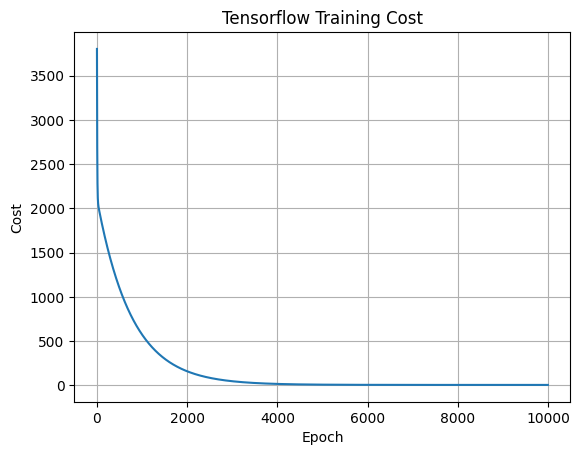

In [11]:
import matplotlib.pyplot as plt

cost_history = history.history['loss']

plt.figure()
plt.plot(cost_history)
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.title('Tensorflow Training Cost')
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


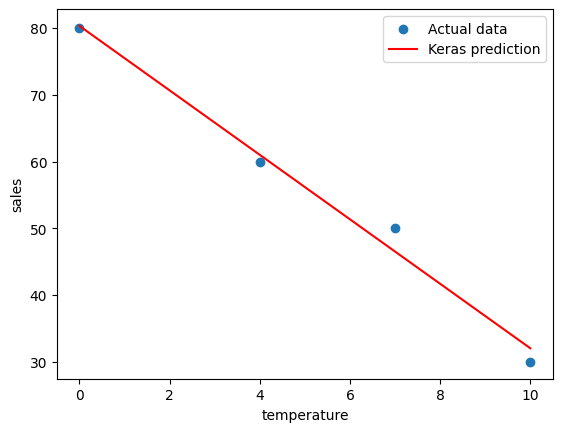

In [12]:
pred_y = model.predict(X)

plt.figure()
plt.scatter(X, y, label='Actual data')
plt.plot(X, pred_y, color='red', label='Keras prediction')
plt.xlabel('temperature')
plt.ylabel('sales')
plt.legend()
plt.show()

In [13]:
new_temperature = np.array([[5]], dtype='float32')
pred_sales = model.predict(new_temperature)

print(f'기온이 5도일 때 예상 판매량: {pred_sales[0][0]:.2f}개')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
기온이 5도일 때 예상 판매량: 56.17개
